In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
print("Loading pure benign data for Autoencoder training...")

X_train_benign = pd.read_parquet('/content/drive/MyDrive/X_train_benign_scaled.parquet')

X_test_scaled = pd.read_parquet('/content/drive/MyDrive/X_test_scaled.parquet')

y_test = pd.read_csv('/content/drive/MyDrive/y_test.csv')['is_attack']


Loading pure benign data for Autoencoder training...


In [12]:
X_train_benign.shape

(1817055, 44)

In [13]:
# Limit the extreme math spikes to keep the neural network stable!
X_train_clipped = np.clip(X_train_benign, -10, 10)
X_test_clipped = np.clip(X_test_scaled, -10, 10)

In [14]:
# Building the AutoEncoder Architecture
print('Building the AutoEncoder Architecture')

# get the number of features dynamically from your scaled data
input_dim = X_train_clipped.shape[1]

# defining  the input layer
input_layer = Input(shape=(input_dim,))

#Encoder: compressing the data
# using relu function for hidden layers to capture non linear network behaviour
x = Dense(64)(input_layer)
x = LeakyReLU(negative_slope=0.1)(x)
x = BatchNormalization()(x)


x = Dense(32)(x)
x = LeakyReLU(negative_slope=0.1)(x)
x = BatchNormalization()(x)

# Bottleneck: core representation of "Normal traffic"
bottleneck = Dense(16, activation='linear')(x)

# Decoder — mirror of encoder exactly
x = Dense(32)(bottleneck)
x = LeakyReLU(negative_slope=0.1)(x)
x = BatchNormalization()(x)

x = Dense(64)(x)
x = LeakyReLU(negative_slope=0.1)(x)
x = BatchNormalization()(x)

# output layer: must match the original input dimension
# using linear activation function because robustScaler allows negaitve and high positive numbers
output_layer = Dense(input_dim, activation='linear')(x)

# compile the model
autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mae')

autoencoder.summary()

print('\nTraining The autoencoder')
# ReduceLROnPlateau: if the model gets stuck, dynamically slow down the learning rate to find the absolute minimum
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr = 1e-5)
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# train only on the normal traffic
# using 10% of training data as validation data to monitor the learning
history = autoencoder.fit(
    X_train_clipped, X_train_clipped,
    epochs=50,
    batch_size=512,
    validation_split=0.1,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Building the AutoEncoder Architecture


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         2,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 44)             │         2,860 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,772 (45.98 KB)

 Trainable params: 11,388 (44.48 KB)

 Non-trainable params: 384 (1.50 KB)


Training The autoencoder
Epoch 1/50
3195/3195 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - loss: 0.3111 - val_loss: 0.1845 - learning_rate: 0.0010
Epoch 2/50
3195/3195 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.1924 - val_loss: 0.1444 - learning_rate: 0.0010
Epoch 3/50
3195/3195 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.1701 - val_loss: 0.1209 - learning_rate: 0.0010
Epoch 4/50
3195/3195 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.1557 - val_loss: 0.1150 - learning_rate: 0.0010
Epoch 5/50
3195/3195 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.1489 - val_loss: 0.1082 - learning_rate: 0.0010
Epoch 6/50
3195/3195 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.1434 - val_loss: 0.1003 - learning_rate: 0.0010
Epoch 7/50
3195/3195 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.1412 - val_loss: 0.0961 - learning_rate: 0.0010
Epoch 8/50
3195/3195 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.1382 - val_loss: 0.0923 - learning_rate: 0.0010
Epoch 9/50
3195/3195 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.1367 

In [15]:
print('calculating reconstruction error')
# reconstructing the test set ( which has both benign and attacks)
reconstructions = autoencoder.predict(X_test_clipped, batch_size=1024)

# calculating the mae b/w the original test data and reconstructions
# High mae = model didn't know how to reconstruct it = anomaly
reconstruction_errors = np.mean(np.abs(X_test_clipped - reconstructions), axis=1)

# reconstruction_errors = (reconstruction_errors - reconstruction_errors.min()) / (reconstruction_errors.max() - reconstruction_errors.min())


calculating reconstruction error
553/553 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [16]:
print('\n threshold tuning ')
# Calculate Precision-Recall curve to find the absolute best mathematical threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, reconstruction_errors)
precisions, recalls = precisions[:-1], recalls[:-1]   # trim the extra point

# calculate f1 score for each threshold and find the best one
f1_scores = 2 * (precisions* recalls) / (precisions + recalls + 1e-10)
best_threshold_index = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_index]

print(f'Best threshold : {best_threshold:.4f}')
print(f'Best F1        : {f1_scores[best_threshold_index ]:.4f}')


 threshold tuning 
Best threshold : 0.1585
Best F1        : 0.5842



 Final Evaluation
Classification Report

              precision    recall  f1-score   support

  Benign (0)       0.89      0.92      0.91    454265
  Attack (1)       0.64      0.54      0.58    111311

    accuracy                           0.85    565576
   macro avg       0.76      0.73      0.75    565576
weighted avg       0.84      0.85      0.84    565576



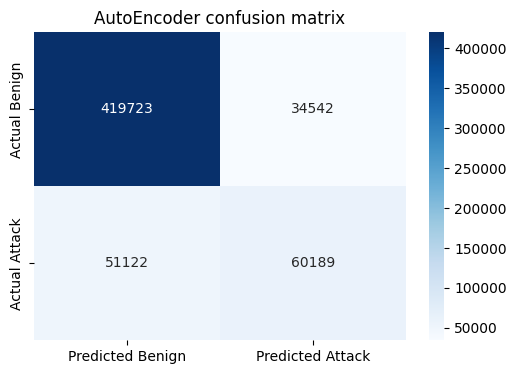

In [17]:
print('\n Final Evaluation')

# if error > best_threshold, flag as attack (1), else benign (0)
final_predictions = (reconstruction_errors > best_threshold).astype(int)

print('Classification Report\n')

print(classification_report(y_test, final_predictions, target_names=['Benign (0)', 'Attack (1)']))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, final_predictions), annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Benign', 'Predicted Attack'], yticklabels=['Actual Benign', 'Actual Attack'])

plt.title('AutoEncoder confusion matrix')
plt.show()


In [ ]:
autoencoder.save('/content/drive/MyDrive/autoencoder_stage2.h5')